# EDA on Train and Test data for Capstone Project

### loading the datasets:

In [27]:
print("Attempting to download NotoSansDevanagari-Regular.ttf...")
!wget "https://github.com/googlefonts/noto-fonts/blob/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf?raw=true" -O NotoSansDevanagari-Regular.ttf

print("\nAttempting to download NotoSansBengali-Regular.ttf...")
!wget "https://github.com/googlefonts/noto-fonts/blob/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf?raw=true" -O NotoSansBengali-Regular.ttf

print("\n--- Download complete ---")
print("Please run the '!ls -l /content/' cell again to confirm you see the .ttf files.")


Attempting to download NotoSansDevanagari-Regular.ttf...
--2025-11-08 17:18:00--  https://github.com/googlefonts/noto-fonts/blob/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf?raw=true
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-fonts/blob/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf?raw=true [following]
--2025-11-08 17:18:01--  https://github.com/notofonts/noto-fonts/blob/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf?raw=true
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/notofonts/noto-fonts/raw/refs/heads/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf [following]
--2025-11-08 17:18:01--  https://github.com/notofonts/noto-fonts/raw/refs/heads/main/hi

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import warnings


warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


def load_json_to_df(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    rows = []
    for lang_pair, splits in data.items():
        for split_name, examples in splits.items():
            for ex_id, content in examples.items():
                row = {
                    'lang_pair': lang_pair,
                    'split': split_name,
                    'id': ex_id,
                    'source_text': content.get('source', np.nan),
                    'target_text': content.get('target', np.nan)
                }
                rows.append(row)

    return pd.DataFrame(rows)

# PATHS
train_filepath = r"/content/test_data1.json"
test_filepath = r"/content/train_data1.json"


try:
    print(f"Loading {train_filepath}...")
    df_train = load_json_to_df(train_filepath)
    print(f"Loaded {len(df_train)} rows from train file.")

    print(f"Loading {test_filepath}...")
    df_test = load_json_to_df(test_filepath)
    print(f"Loaded {len(df_test)} rows from test file.")

    df = pd.concat([df_train, df_test], ignore_index=True)
    print(f"\nTotal Combined Data Shape: {df.shape}")

except FileNotFoundError as e:
    print(f"\nERROR: {e}")
    print("Please ensure the JSON file paths are correct.")
    df = pd.DataFrame(columns=['lang_pair', 'split', 'id', 'source_text', 'target_text'])

display(df.head())
display(df.info())

Loading /content/test_data1.json...
Loaded 42757 rows from train file.
Loading /content/train_data1.json...
Loaded 149646 rows from test file.

Total Combined Data Shape: (192403, 5)


,lang_pair,split,id,source_text,target_text
0,English-Bengali,Test,177039,current events,NaN
1,English-Bengali,Test,177040,The god Brahma was pleased with her penance bu...,NaN
2,English-Bengali,Test,177041,After feeling stiffness in chest or heaviness ...,NaN
3,English-Bengali,Test,177042,As it dawns on him that the baby is in fact hi...,NaN
4,English-Bengali,Test,177043,Australia produces significant amounts of lent...,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192403 entries, 0 to 192402
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   lang_pair    192403 non-null  object
 1   split        192403 non-null  object
 2   id           192403 non-null  object
 3   source_text  192403 non-null  object
 4   target_text  149646 non-null  object
dtypes: object(5)
memory usage: 7.3+ MB


None

In [ ]:
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicates ---")
duplicates = df[df.duplicated(subset=['lang_pair', 'source_text', 'target_text'], keep=False)]
print(f"Number of duplicate sentence pairs: {len(duplicates)}")

print("\n--- Data Distribution by Pair and Split ---")
print(df.groupby(['lang_pair', 'split']).size())

--- Missing Values ---
lang_pair          0
split              0
id                 0
source_text        0
target_text    42757
dtype: int64

--- Duplicates ---
Number of duplicate sentence pairs: 2791

--- Data Distribution by Pair and Split ---
lang_pair        split
English-Bengali  Test     19672
                 Train    68849
English-Hindi    Test     23085
                 Train    80797
dtype: int64


In [ ]:
def basic_tokenizer(text):
    if not isinstance(text, str):
        return []
    translator = str.maketrans('', '', string.punctuation + '।')
    clean_text = text.translate(translator).lower()
    return clean_text.split()

print("Calculating sentence lengths...")
df['source_len_char'] = df['source_text'].astype(str).apply(len)
df['target_len_char'] = df['target_text'].astype(str).apply(len)

df['source_tokens'] = df['source_text'].apply(basic_tokenizer)
df['target_tokens'] = df['target_text'].apply(basic_tokenizer)

df['source_len_tokens'] = df['source_tokens'].apply(len)
df['target_len_tokens'] = df['target_tokens'].apply(len)

print("Done.")
display(df.head(3))

Calculating sentence lengths...
Done.


,lang_pair,split,id,source_text,target_text,source_len_char,target_len_char,source_tokens,target_tokens,source_len_tokens,target_len_tokens
0,English-Bengali,Test,177039,current events,NaN,14,3,"[current, events]",[],2,0
1,English-Bengali,Test,177040,The god Brahma was pleased with her penance bu...,NaN,140,3,"[the, god, brahma, was, pleased, with, her, pe...",[],25,0
2,English-Bengali,Test,177041,After feeling stiffness in chest or heaviness ...,NaN,123,3,"[after, feeling, stiffness, in, chest, or, hea...",[],20,0


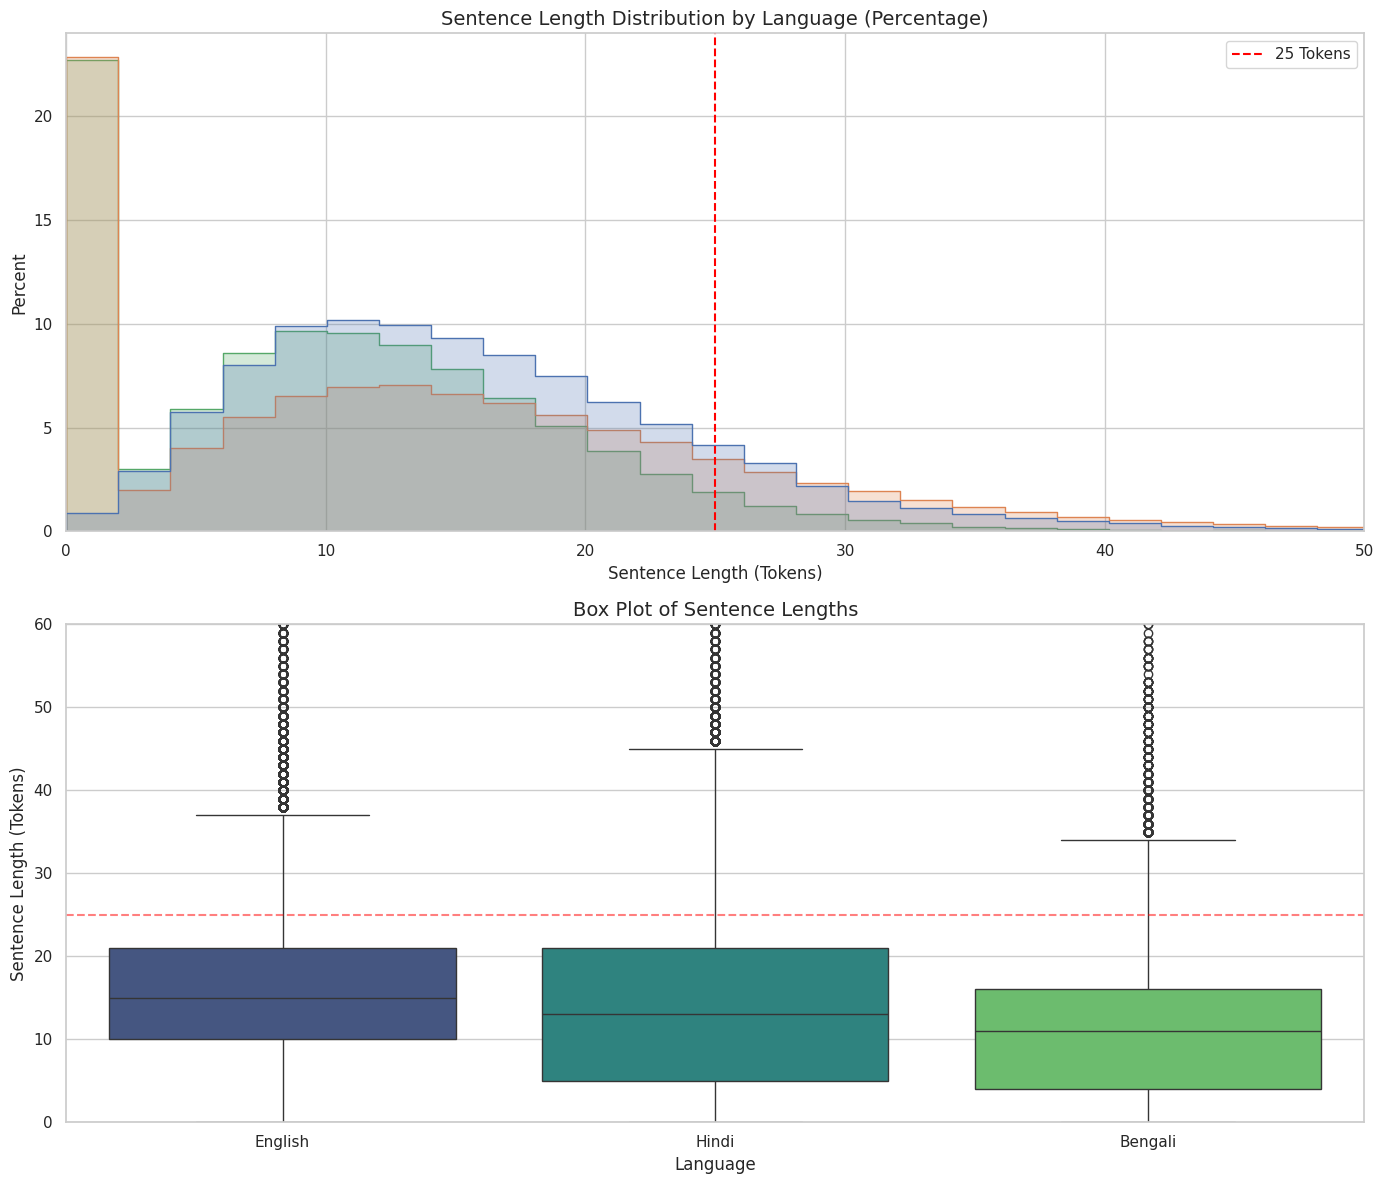

Percentage of sentences <= 25 tokens:
English: 86.53%
Hindi:   84.28%
Bengali: 95.39%


In [ ]:

eng_lengths = df['source_len_tokens'].dropna()
hin_lengths = df[df['lang_pair'].str.contains('Hindi', case=False)]['target_len_tokens'].dropna()
ben_lengths = df[df['lang_pair'].str.contains('Bengali', case=False)]['target_len_tokens'].dropna()

plot_data = pd.DataFrame({
    'Language': ['English']*len(eng_lengths) + ['Hindi']*len(hin_lengths) + ['Bengali']*len(ben_lengths),
    'Sentence Length (Tokens)': np.concatenate([eng_lengths, hin_lengths, ben_lengths])
})

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.histplot(data=plot_data, x="Sentence Length (Tokens)", hue="Language", element="step",
             stat="percent", common_norm=False, binwidth=2, ax=axes[0])
axes[0].set_title('Sentence Length Distribution by Language (Percentage)', fontsize=14)
axes[0].set_xlim(0, 50) 
axes[0].axvline(25, color='red', linestyle='--', label='25 Tokens')
axes[0].legend()


sns.boxplot(data=plot_data, x="Language", y="Sentence Length (Tokens)", ax=axes[1], palette='viridis')
axes[1].set_title('Box Plot of Sentence Lengths', fontsize=14)
axes[1].set_ylim(0, 60) 
axes[1].axhline(25, color='red', linestyle='--', alpha=0.5, label='25 Tokens')

plt.tight_layout()
plt.show()

print("Percentage of sentences <= 25 tokens:")
print(f"English: {(eng_lengths <= 25).mean()*100:.2f}%")
print(f"Hindi:   {(hin_lengths <= 25).mean()*100:.2f}%")
print(f"Bengali: {(ben_lengths <= 25).mean()*100:.2f}%")

Using Hindi font from: /content/NotoSansDevanagari-Regular.ttf
Using Bengali font from: /content/NotoSansBengali-Regular.ttf


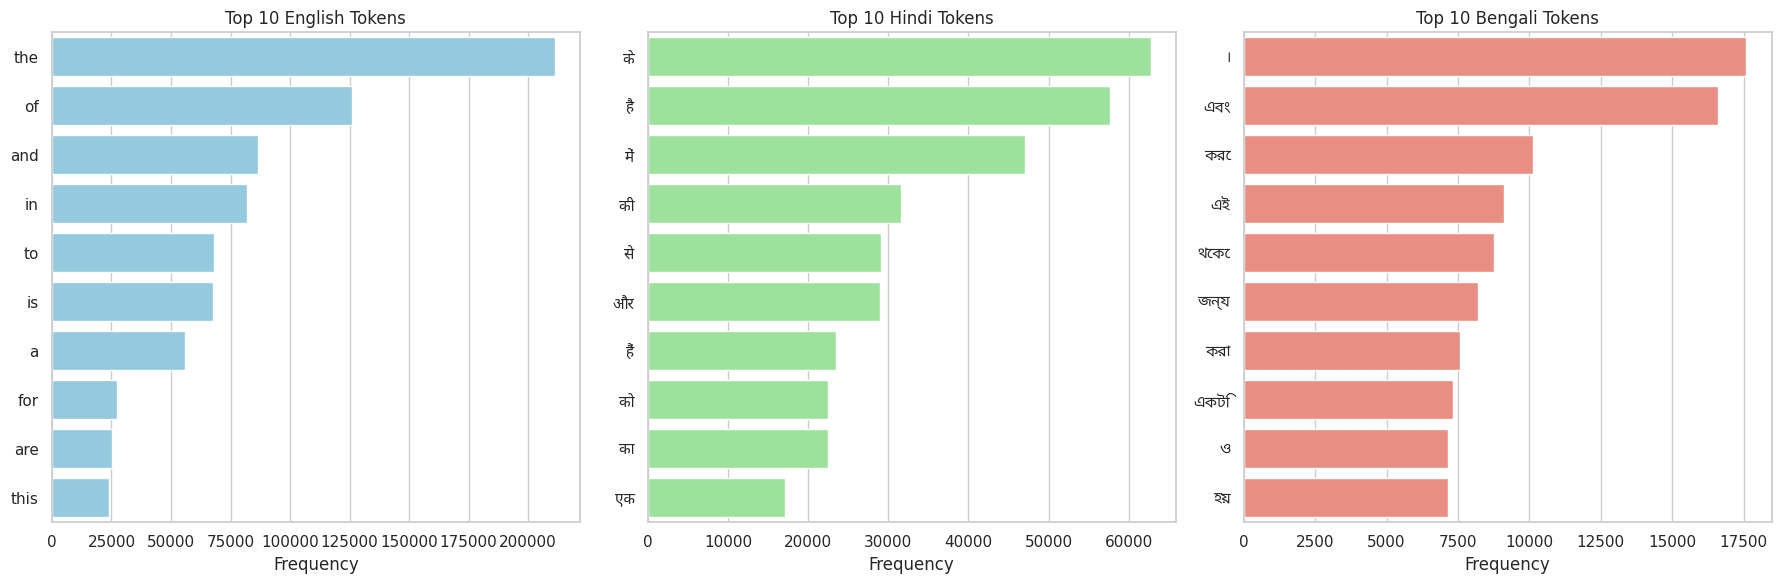

In [ ]:
import matplotlib.font_manager as fm
import os.path

hindi_font_path = '/content/NotoSansDevanagari-Regular.ttf'
bengali_font_path = '/content/NotoSansBengali-Regular.ttf'

if os.path.exists(hindi_font_path) and os.path.exists(bengali_font_path):
    print(f"Using Hindi font from: {hindi_font_path}")
    print(f"Using Bengali font from: {bengali_font_path}")
    font_prop_hin = fm.FontProperties(fname=hindi_font_path, size=11)
    font_prop_ben = fm.FontProperties(fname=bengali_font_path, size=11)
else:
    print(f"--- FONT ERROR ---")
    print("Could not find downloaded fonts. Please re-run the `!wget` cell above.")
    print("Using default system font as a fallback (will likely show boxes ◻).")
    font_prop_hin = fm.FontProperties()
    font_prop_ben = fm.FontProperties()


def get_top_tokens(token_series, n=10):
    all_tokens = [token for sublist in token_series for token in sublist]
    return Counter(all_tokens).most_common(n)

top_eng = get_top_tokens(df['source_tokens'])
top_hin = get_top_tokens(df[df['lang_pair'].str.contains('Hindi', case=False)]['target_tokens'])
top_ben = get_top_tokens(df[df['lang_pair'].str.contains('Bengali', case=False)]['target_tokens'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if top_eng:
    tokens_e, counts_e = zip(*top_eng)
    sns.barplot(x=list(counts_e), y=list(tokens_e), ax=axes[0], color="skyblue")
    axes[0].set_title("Top 10 English Tokens")
    axes[0].set_xlabel("Frequency")

if top_hin:
    tokens_h, counts_h = zip(*top_hin)
    sns.barplot(x=list(counts_h), y=list(tokens_h), ax=axes[1], color="lightgreen")
    axes[1].set_title("Top 10 Hindi Tokens")
    axes[1].set_xlabel("Frequency")
    axes[1].set_yticklabels(tokens_h, fontproperties=font_prop_hin)

if top_ben:
    tokens_b, counts_b = zip(*top_ben)
    sns.barplot(x=list(counts_b), y=list(tokens_b), ax=axes[2], color="salmon")
    axes[2].set_title("Top 10 Bengali Tokens")
    axes[2].set_xlabel("Frequency")
    axes[2].set_yticklabels(tokens_b, fontproperties=font_prop_ben)

plt.tight_layout()
plt.show()

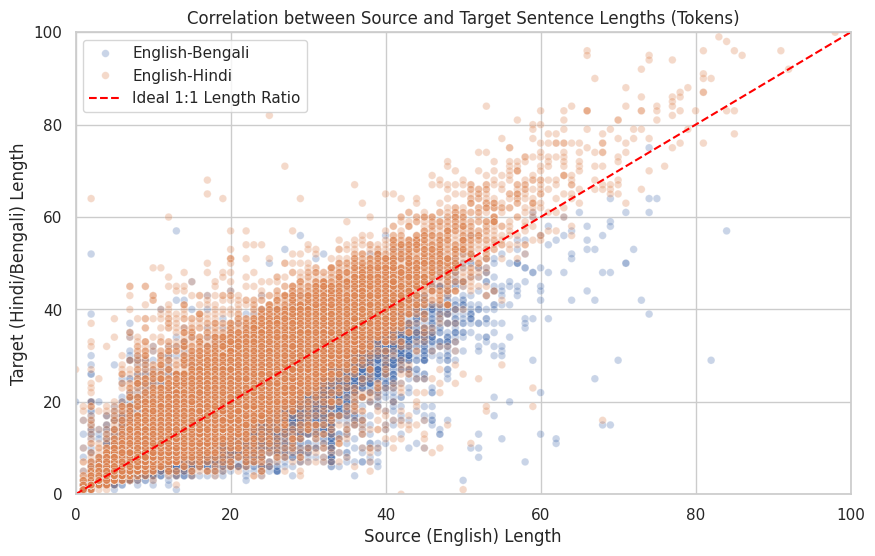

Pearson Correlation between Source and Target Lengths:
lang_pair                         
English-Bengali  source_len_tokens    0.882363
English-Hindi    source_len_tokens    0.921384
Name: target_len_tokens, dtype: float64


In [ ]:

train_only = df[df['split'] == 'Train'].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_only, x="source_len_tokens", y="target_len_tokens",
                hue="lang_pair", alpha=0.3, s=30)

max_val = max(train_only['source_len_tokens'].max(), train_only['target_len_tokens'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Ideal 1:1 Length Ratio')

plt.title("Correlation between Source and Target Sentence Lengths (Tokens)")
plt.xlabel("Source (English) Length")
plt.ylabel("Target (Hindi/Bengali) Length")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()

corrs = train_only.groupby('lang_pair')[['source_len_tokens', 'target_len_tokens']].corr().iloc[0::2, -1]
print("Pearson Correlation between Source and Target Lengths:")
print(corrs)

In [14]:
def get_vocab_stats(token_series):
    all_tokens = [token for sublist in token_series for token in sublist]
    unique_tokens = set(all_tokens)
    total_tokens = len(all_tokens)
    return len(unique_tokens), total_tokens

vocab_eng, total_eng = get_vocab_stats(df['source_tokens'])
vocab_hin, total_hin = get_vocab_stats(df[df['lang_pair'].str.contains('Hindi', case=False)]['target_tokens'])
vocab_ben, total_ben = get_vocab_stats(df[df['lang_pair'].str.contains('Bengali', case=False)]['target_tokens'])

stats_df = pd.DataFrame({
    'Language': ['English', 'Hindi', 'Bengali'],
    'Vocabulary Size (Unique Tokens)': [vocab_eng, vocab_hin, vocab_ben],
    'Total Tokens': [total_eng, total_hin, total_ben]
})
stats_df['Type-Token Ratio'] = stats_df['Vocabulary Size (Unique Tokens)'] / stats_df['Total Tokens']

print("--- Vocabulary Statistics ---")
display(stats_df.set_index('Language'))

--- Vocabulary Statistics ---


,Vocabulary Size (Unique Tokens),Total Tokens,Type-Token Ratio
Language,,,
English,87542,3146481,0.027822
Hindi,78109,1471071,0.053097
Bengali,102935,956301,0.107639
